In [4]:
import tensorflow as tf
from keras.src.applications.resnet import ResNet50
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers, models, Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.resnet50 import preprocess_input
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [5]:
def create_species_extinction_map():
    df = pd.read_csv('C:/Users/Natalia/Desktop/PADIA/endansys/etiquetas_animales.csv')
    extinction_map = df.groupby('species')['status'].first().to_dict()
    return extinction_map

print(create_species_extinction_map())

{'aguila arpia': 1, 'anaconda': 0, 'armadillo gigante': 0, 'boa constrictor': 0, 'buho cornudo': 0, 'cacique candela': 0, 'caiman aguja': 0, 'capibara': 0, 'caracara': 0, 'colibri esmeralda': 0, 'condor de los andes': 1, 'cusumbo': 0, 'delfin rosado': 1, 'flamenco': 0, 'gallito de roca': 0, 'garza blanca': 0, 'guacamaya azulamarilla': 1, 'guacamaya roja': 1, 'guatin': 0, 'hormiguero gigante': 0, 'iguana verde': 0, 'jaguar': 1, 'jaguarundi': 0, 'lagarto azul': 0, 'loro orejiamarillo': 0, 'manati del caribe': 1, 'marimonda': 0, 'martin pescador': 0, 'mico titi gris': 1, 'mono aullador': 0, 'mono lanudo': 0, 'mono nocturno': 0, 'musarana de cola corta colombiana': 0, 'neque': 0, 'nutria gigante': 1, 'oso andino': 0, 'oso de anteojos': 1, 'paujil': 0, 'pecari de collar': 0, 'perezoso de dos dedos': 0, 'perico carisucio': 0, 'perro de monte': 0, 'puma': 0, 'rana de cristal': 0, 'rana dorada': 1, 'rana venenosa azul': 0, 'tapaculo': 0, 'tapir amazonico': 1, 'tigrillo': 1, 'tinamu': 0, 'titi 

In [7]:
from sklearn.metrics import classification_report

img_size = (224, 224)
batch_size = 32

train_ds = image_dataset_from_directory(
    'C:/Users/Natalia/Desktop/PADIA/endansys/datasetN/training',
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

val_ds = image_dataset_from_directory(
    'C:/Users/Natalia/Desktop/PADIA/endansys/datasetN/validation',
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds = image_dataset_from_directory(
    'C:/Users/Natalia/Desktop/PADIA/endansys/datasetN/testing',
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1, 0.1),
])

base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = False

model = models.Sequential([
    data_augmentation,
    layers.Resizing(224, 224),
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(train_ds.class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stopping = EarlyStopping(
    patience=10,
    restore_best_weights=True
)

model.fit(train_ds,
          validation_data=val_ds,
          epochs=25,
          callbacks=[early_stopping])

def calculate_detailed_metrics(model, dataset, dataset_name, class_names):
    print(f"\n=== Métricas para {dataset_name} ===")

    # Obtener predicciones y etiquetas verdaderas
    y_true = []
    y_pred = []

    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        predicted_classes = np.argmax(predictions, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted_classes)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Calcular accuracy manualmente para verificar
    accuracy = np.mean(y_true == y_pred)
    print(f"Accuracy: {accuracy:.4f} ({accuracy:.2%})")

    # Reporte de clasificación con precision, recall y F1-score
    print("\nReporte de clasificación:")
    report = classification_report(y_true, y_pred,
                                 target_names=class_names,
                                 digits=4)
    print(report)

print("ANTES DEL FINE-TUNING:")
val_loss, val_acc = model.evaluate(val_ds)
print(f"Precisión en validación: {val_acc:.2%}")

test_loss, test_acc = model.evaluate(test_ds)
print(f"Precisión en test: {test_acc:.2%}")

# Métricas detalladas antes del fine-tuning
calculate_detailed_metrics(model, val_ds, "Validación (antes fine-tuning)", train_ds.class_names)
calculate_detailed_metrics(model, test_ds, "Test (antes fine-tuning)", train_ds.class_names)

val_loss, val_acc = model.evaluate(val_ds)
print(f"Precisión en validación: {val_acc:.2%}")

test_loss, test_acc = model.evaluate(test_ds)
print(f"Precisión en test: {test_acc:.2%}")

#Aqui empieza el fine-tuning
base_model.trainable = True
fine_tune = 140

for layer in base_model.layers[:fine_tune]:
    layer.trainable = False

#Recompilar con un learning mas bajo para el fine-tuning
model.compile(optimizer=tf.keras.optimizers.Adam(0.000001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#Entrenamiento fine-tuning
model.fit(train_ds,
          validation_data=val_ds,
          epochs=20,
          callbacks=[early_stopping])

val_loss, val_acc = model.evaluate(val_ds)
print(f"Precisión en validación con fine-tuning: {val_acc:.2%}")

test_loss, test_acc = model.evaluate(test_ds)
print(f"Precisión en test con fine-tuning: {test_acc:.2%}")

calculate_detailed_metrics(model, val_ds, "Validación (después fine-tuning)", train_ds.class_names)
calculate_detailed_metrics(model, test_ds, "Test (después fine-tuning)", train_ds.class_names)

Found 2827 files belonging to 56 classes.
Found 564 files belonging to 56 classes.
Found 702 files belonging to 56 classes.
Epoch 1/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 68s 731ms/step - accuracy: 0.0719 - loss: 3.9612 - val_accuracy: 0.4734 - val_loss: 2.3821
Epoch 2/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 65s 731ms/step - accuracy: 0.2932 - loss: 2.7759 - val_accuracy: 0.7074 - val_loss: 1.3566
Epoch 3/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 60s 674ms/step - accuracy: 0.4250 - loss: 2.1552 - val_accuracy: 0.7766 - val_loss: 0.9721
Epoch 4/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 62s 703ms/step - accuracy: 0.4919 - loss: 1.8360 - val_accuracy: 0.7784 - val_loss: 0.8301
Epoch 5/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 66s 746ms/step - accuracy: 0.5354 - loss: 1.6342 - val_accuracy: 0.8103 - val_loss: 0.7381
Epoch 6/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 76s 854ms/step - accuracy: 0.5815 - loss: 1.4536 - val_accuracy: 0.8103 - val_loss: 0.6609
Epoch 7/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 76s 858ms/step - accuracy: 0.5901 - loss: 1.4073 - val_accuracy:

In [8]:
import json
class_names_modified = [
    name.lower()
    .replace("_peligro", "")
    .replace("_", " ")
    .strip()
    for name in train_ds.class_names
]

In [11]:
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np

img_path = "C:/Users/Natalia/Desktop/PADIA/endansys/dataset/testing/Tapaculo/18.jpg"  # Cambia esto por la ruta de tu imagen
img_size = (224, 224)

# Cargar imagen y redimensionar
img = load_img(img_path, target_size=img_size)

# Convertir a array y escalar
img_array = img_to_array(img)
img_array = preprocess_input(img_array)  # Normalizar igual que en el modelo

# Expandir dimensiones para simular un batch de tamaño 1
img_array = np.expand_dims(img_array, axis=0)

predictions = model.predict(img_array)
class_names = train_ds.class_names

predicted_class = np.argmax(predictions[0])
confidence = 100 * np.max(predictions[0])

print(f"La imagen probablemente pertenece a '{class_names_modified[predicted_class]}' con una confianza de {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
La imagen probablemente pertenece a 'tapaculo' con una confianza de 44.87%


In [12]:
especies = create_species_extinction_map()
if especies[class_names_modified[predicted_class]] == '1':
    print(f'El animal {class_names_modified[predicted_class]} está en peligro de extinción')
else:
    print(f'El animal {class_names_modified[predicted_class]} no está en peligro de extinción')

El animal tapaculo no está en peligro de extinción


22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 585ms/step

10 clases seleccionadas aleatoriamente (excluyendo 100% accuracy):
Clase                Accuracy   Muestras  
Capibara             0.8182     11        
Mono_nocturno        0.7857     14        
Perro_de_monte       0.6429     14        
Guatin               0.7500     12        
Loro_orejiamarillo   0.9286     14        
Jaguar_peligro       0.9167     12        
Flamenco             0.9286     14        
Oso_de_anteojos_peligro 0.8750     16        
Puma                 0.8667     15        
Neque                0.1429     7         


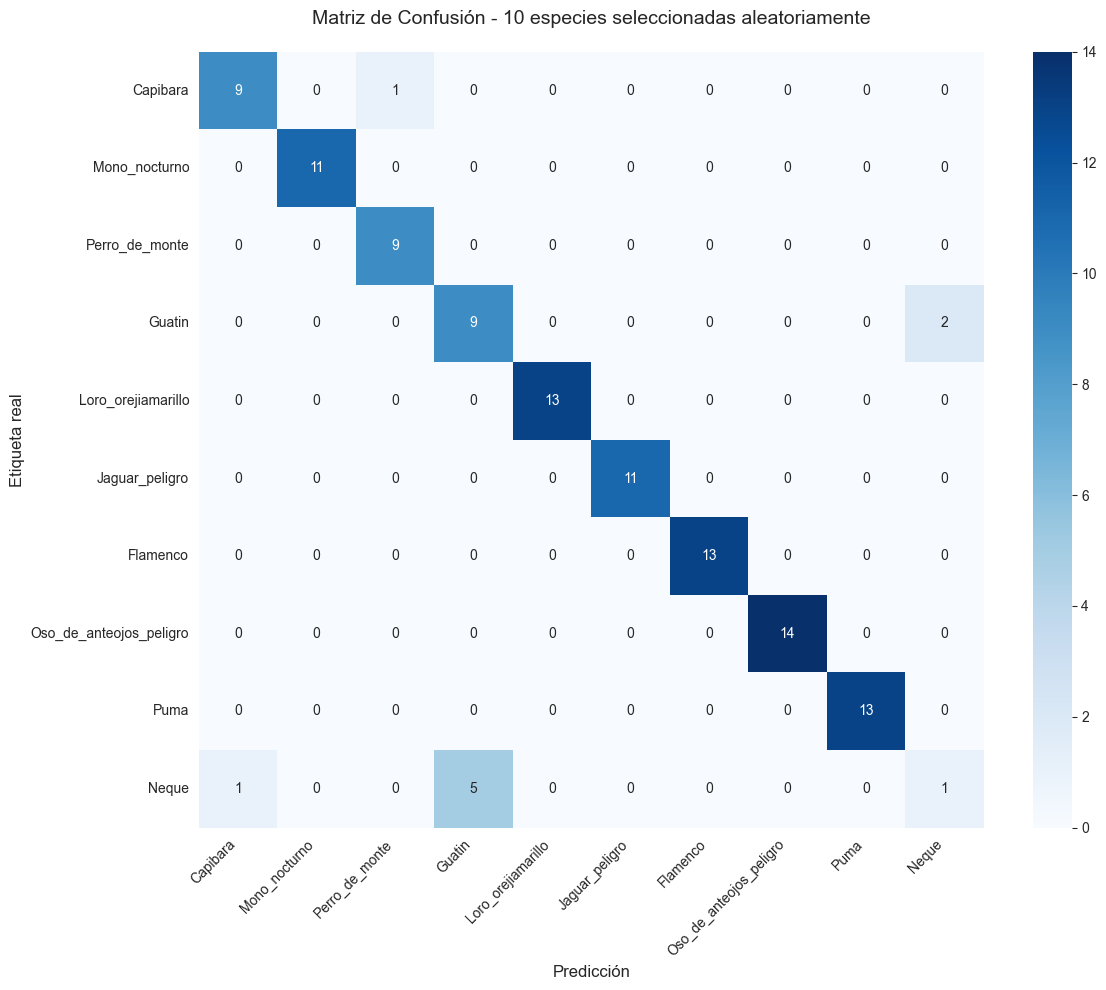


Estadísticas de la matriz filtrada:
Muestras en las 10 clases aleatorias: 112
Porcentaje del dataset original: 16.0%
Accuracy promedio: 91.96%


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Obtener predicciones
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Matriz de confusión completa
cm_full = confusion_matrix(y_true, y_pred)
labels = train_ds.class_names

# Calcular accuracy por clase (diagonal de la matriz normalizada)
class_accuracies = []
for i in range(len(labels)):
    tp = cm_full[i, i]
    total_samples = np.sum(cm_full[i, :])
    accuracy = tp / total_samples if total_samples > 0 else 0
    class_accuracies.append((i, labels[i], accuracy, total_samples))

# Seleccionar 10 clases aleatoriamente (excluyendo las con 100% accuracy si se desea)
filtered_classes = [item for item in class_accuracies if item[2] < 1.0]  # Opcional: excluir 100%
if len(filtered_classes) < 10:
    print(f"¡Advertencia: Solo hay {len(filtered_classes)} clases con accuracy < 100%.")
    # Usar todas las clases disponibles si hay menos de 10
    sampled_classes = filtered_classes
else:
    # Seleccionar 10 aleatoriamente
    sampled_classes = [filtered_classes[i] for i in np.random.choice(len(filtered_classes), size=10, replace=False)]

# Mostrar clases seleccionadas aleatoriamente
print("\n10 clases seleccionadas aleatoriamente (excluyendo 100% accuracy):")
print("=" * 60)
print(f"{'Clase':<20} {'Accuracy':<10} {'Muestras':<10}")
print("=" * 60)
for idx, class_name, acc, samples in sampled_classes:
    print(f"{class_name:<20} {acc:<10.4f} {samples:<10}")

# Extraer índices y nombres de las clases seleccionadas
random10_indices = [item[0] for item in sampled_classes]
random10_labels = [item[1] for item in sampled_classes]

# Mapeo de índices originales a nuevos índices
old_to_new_idx = {old_idx: new_idx for new_idx, old_idx in enumerate(random10_indices)}

# Filtrar predicciones y etiquetas verdaderas
y_true_filtered = []
y_pred_filtered = []
for true_label, pred_label in zip(y_true, y_pred):
    if true_label in random10_indices and pred_label in random10_indices:
        y_true_filtered.append(old_to_new_idx[true_label])
        y_pred_filtered.append(old_to_new_idx[pred_label])

y_true_filtered = np.array(y_true_filtered)
y_pred_filtered = np.array(y_pred_filtered)

# Matriz de confusión para las clases aleatorias
cm_random10 = confusion_matrix(y_true_filtered, y_pred_filtered)

# Visualización
plt.figure(figsize=(12, 10))
sns.heatmap(cm_random10, annot=True, fmt="d", cmap="Blues",
            xticklabels=random10_labels,
            yticklabels=random10_labels)
plt.xlabel("Predicción", fontsize=12)
plt.ylabel("Etiqueta real", fontsize=12)
plt.title("Matriz de Confusión - 10 especies seleccionadas aleatoriamente", fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Estadísticas
print(f"\nEstadísticas de la matriz filtrada:")
print(f"Muestras en las 10 clases aleatorias: {np.sum(cm_random10)}")
print(f"Porcentaje del dataset original: {np.sum(cm_random10)/len(y_true)*100:.1f}%")
print(f"Accuracy promedio: {np.trace(cm_random10)/np.sum(cm_random10):.2%}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 588ms/step


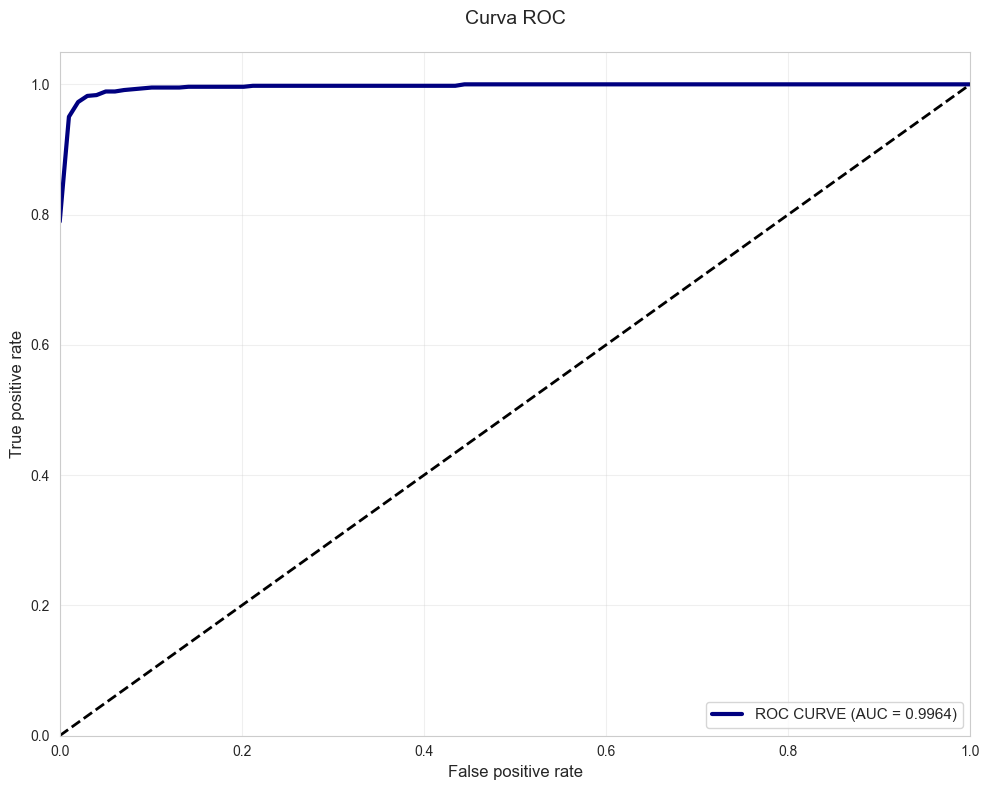

MÉTRICA ROC MACRO-AVERAGE
ROC CURVE: 0.9964



<Figure size 640x480 with 0 Axes>

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Obtener probabilidades de predicción y etiquetas verdaderas
y_pred_probs = model.predict(test_ds)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Obtener nombres de clases
class_names = train_ds.class_names
n_classes = len(class_names)

# Binarizar las etiquetas verdaderas (one-hot encoding)
y_true_binarized = label_binarize(y_true, classes=range(n_classes))

# Si solo hay 2 clases, ajustar la binarización
if n_classes == 2:
    y_true_binarized = np.hstack([1 - y_true_binarized, y_true_binarized])

# Calcular curva ROC para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcular ROC micro-average (considera todas las predicciones de todas las clases)
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Calcular ROC macro-average (promedio de las AUC individuales)
macro_auc = np.mean([roc_auc[i] for i in range(n_classes)])

# Para la curva macro-average, calculamos el promedio de los puntos de las curvas individuales
# Crear un conjunto común de puntos FPR
common_fpr = np.linspace(0, 1, 100)
tpr_interp = []

for i in range(n_classes):
    # Interpolar manualmente cada curva TPR a los puntos FPR comunes
    tpr_interp.append(np.interp(common_fpr, fpr[i], tpr[i]))

# Calcular el promedio de las TPR interpoladas
mean_tpr = np.mean(tpr_interp, axis=0)
fpr["macro"] = common_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Visualizar solo la curva ROC Macro-average
plt.figure(figsize=(10, 8))

# Curva ROC Macro-average
plt.plot(fpr["macro"], tpr["macro"],
         label=f'ROC CURVE (AUC = {roc_auc["macro"]:.4f})',
         color='navy', linewidth=3)

# Línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2)


# Configuración del gráfico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False positive rate', fontsize=12)
plt.ylabel('True positive rate', fontsize=12)
plt.title('Curva ROC', fontsize=14, pad=20)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar métricas
print("MÉTRICA ROC MACRO-AVERAGE")
print("=" * 40)
print(f"ROC CURVE: {roc_auc['macro']:.4f}")
print()

plt.tight_layout()
plt.show()

22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 572ms/step
Clase 0 (Aguila_arpia_peligro): Accuracy = 0.8462
Clase 1 (Anaconda): Accuracy = 0.9231
Clase 2 (Armadillo_gigante): Accuracy = 1.0000
Clase 3 (Boa_constrictor): Accuracy = 0.9231
Clase 4 (Buho_cornudo): Accuracy = 1.0000
Clase 5 (Cacique_candela): Accuracy = 1.0000
Clase 6 (Caiman_aguja): Accuracy = 0.9231
Clase 7 (Capibara): Accuracy = 0.8182
Clase 8 (Caracara): Accuracy = 1.0000
Clase 9 (Colibri_esmeralda): Accuracy = 1.0000
Clase 10 (Condor_de_los_Andes_peligro): Accuracy = 0.9286
Clase 11 (Cusumbo): Accuracy = 0.7692
Clase 12 (Delfin_rosado_peligro): Accuracy = 1.0000
Clase 13 (Flamenco): Accuracy = 0.9286
Clase 14 (Gallito_de_roca): Accuracy = 0.8182
Clase 15 (Garza_blanca): Accuracy = 1.0000
Clase 16 (Guacamaya_azulamarilla_peligro): Accuracy = 0.7500
Clase 17 (Guacamaya_roja_peligro): Accuracy = 1.0000
Clase 18 (Guatin): Accuracy = 0.7500
Clase 19 (Hormiguero_gigante): Accuracy = 0.8333
Clase 20 (Iguana_verde): Accuracy = 1.0000
Clase 2

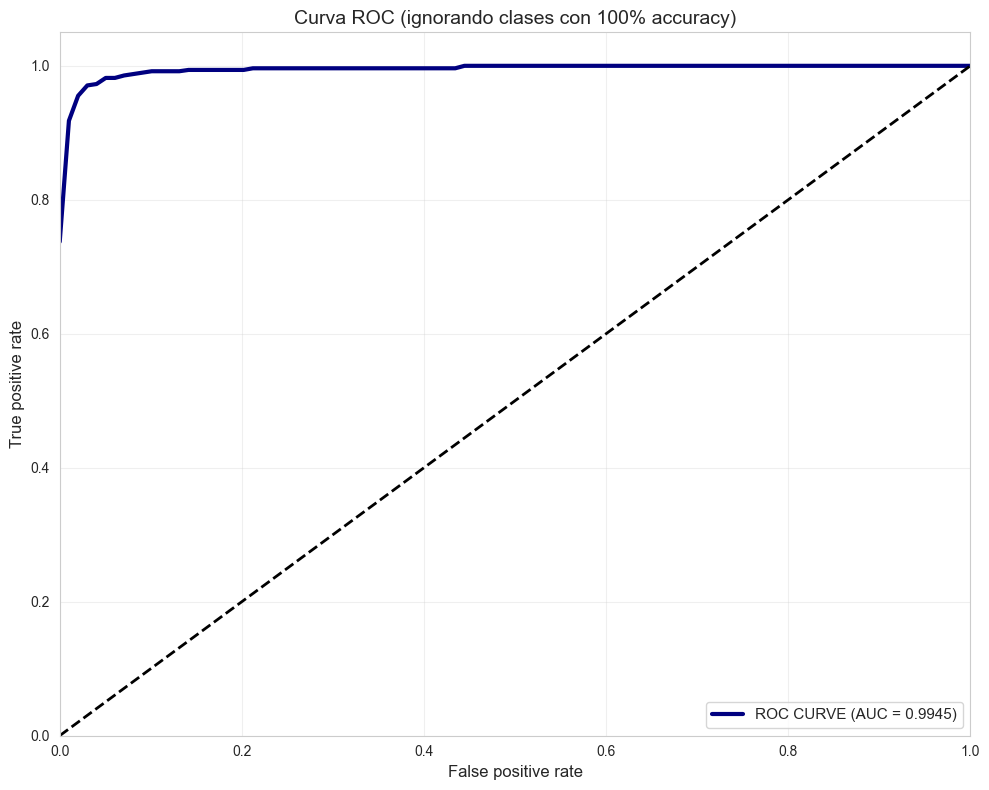


MÉTRICA ROC MACRO-AVERAGE (sin clases con 100% accuracy)
ROC CURVE: 0.9945

Clases incluidas: ['Aguila_arpia_peligro', 'Anaconda', 'Boa_constrictor', 'Caiman_aguja', 'Capibara', 'Condor_de_los_Andes_peligro', 'Cusumbo', 'Flamenco', 'Gallito_de_roca', 'Guacamaya_azulamarilla_peligro', 'Guatin', 'Hormiguero_gigante', 'Jaguar_peligro', 'Jaguarundi', 'Lagarto_azul', 'Loro_orejiamarillo', 'Mico_titi_gris_peligro', 'Mono_lanudo', 'Mono_nocturno', 'Neque', 'Nutria_gigante_peligro', 'Oso_andino', 'Oso_de_anteojos_peligro', 'Pecari_de_collar', 'Perico_carisucio', 'Perro_de_monte', 'Puma', 'Rana_venenosa_azul', 'Tapaculo', 'Tigrillo_peligro', 'Tinamu', 'Venado_cola_blanca', 'Zorrillo_listado', 'Zorro_cangrejero']

Accuracy por clase incluida:
  Aguila_arpia_peligro: 0.8462
  Anaconda: 0.9231
  Boa_constrictor: 0.9231
  Caiman_aguja: 0.9231
  Capibara: 0.8182
  Condor_de_los_Andes_peligro: 0.9286
  Cusumbo: 0.7692
  Flamenco: 0.9286
  Gallito_de_roca: 0.8182
  Guacamaya_azulamarilla_peligro: 0.7

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.preprocessing import label_binarize

# Obtener probabilidades y etiquetas
y_pred_probs = model.predict(test_ds)
y_true = np.concatenate([y for x, y in test_ds], axis=0)
class_names = train_ds.class_names
n_classes = len(class_names)

# Binarizar etiquetas verdaderas
y_true_binarized = label_binarize(y_true, classes=range(n_classes))
if n_classes == 2:
    y_true_binarized = np.hstack([1 - y_true_binarized, y_true_binarized])

# Etiquetas predichas (clase con mayor probabilidad)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Calcular accuracy por clase (método corregido)
accuracies = []
for i in range(n_classes):
    # Crear máscara para muestras de la clase i
    mask_true = (y_true == i)
    mask_pred = (y_pred_labels == i)

    # Calcular accuracy específica de la clase
    if np.sum(mask_true) > 0:  # Si la clase tiene muestras verdaderas
        # True Positives para esta clase
        tp = np.sum(mask_true & mask_pred)
        # Total de muestras verdaderas de esta clase
        total_true = np.sum(mask_true)
        # Accuracy de la clase = TP / Total_verdaderos
        class_accuracy = tp / total_true
        accuracies.append(class_accuracy)
        print(f"Clase {i} ({class_names[i]}): Accuracy = {class_accuracy:.4f}")
    else:
        accuracies.append(0.0)
        print(f"Clase {i} ({class_names[i]}): Sin muestras")

# Filtrar clases con accuracy < 1.0 (ignora las que tienen 100%)
valid_classes = [i for i, acc in enumerate(accuracies) if acc < 1.0]

print(f"\nClases con accuracy < 100%: {[class_names[i] for i in valid_classes]}")
print(f"Clases ignoradas (accuracy = 100%): {[class_names[i] for i in range(n_classes) if i not in valid_classes]}")

# Si todas las clases tienen accuracy perfecta, usar todas
if len(valid_classes) == 0:
    print("¡Todas las clases tienen accuracy perfecta! Usando todas las clases.")
    valid_classes = list(range(n_classes))

# Calcular curvas ROC solo para clases válidas
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in valid_classes:
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized[:, valid_classes].ravel(),
                                          y_pred_probs[:, valid_classes].ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average
common_fpr = np.linspace(0, 1, 100)
tpr_interp = []

for i in valid_classes:
    tpr_interp.append(np.interp(common_fpr, fpr[i], tpr[i]))

mean_tpr = np.mean(tpr_interp, axis=0)
fpr["macro"] = common_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Visualizar curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr["macro"], tpr["macro"],
         label=f'ROC CURVE (AUC = {roc_auc["macro"]:.4f})',
         color='navy', linewidth=3)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False positive rate', fontsize=12)
plt.ylabel('True positive rate', fontsize=12)
plt.title('Curva ROC (ignorando clases con 100% accuracy)', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar métricas
print("\nMÉTRICA ROC MACRO-AVERAGE (sin clases con 100% accuracy)")
print("=" * 50)
print(f"ROC CURVE: {roc_auc['macro']:.4f}")
print("\nClases incluidas:", [class_names[i] for i in valid_classes])

# Mostrar accuracy de cada clase incluida
print("\nAccuracy por clase incluida:")
for i in valid_classes:
    print(f"  {class_names[i]}: {accuracies[i]:.4f}")